# 📈 Forecasting de revenue — Happy Cow Ice Cream

> ### **Integrantes**
> #### Santiago Bazzani Rincon
> #### Brayan Presiga Sepulveda

## Créditos

Este notebook está basado en el caso de estudio:

> **Caso N.° HK1207-PDF-ENG**  
> University of Hong Kong / Harvard Business Publishing Education  
> Disponible en: https://hbsp.harvard.edu/product/HK1207-PDF-ENG

El material del caso es propiedad de la University of Hong Kong y distribuido por Harvard Business Publishing. Su uso en este curso es exclusivamente con fines académicos.

---

## Contexto e introducción

En el caso de Happy Cow Ice Cream se busca desarrollar un modelo de forecasting a partir de datos diarios de ventas por producto, con el fin de apoyar decisiones de negocio 📊. Dado el alto nivel de ruido y variabilidad presente en la información diaria, el análisis se enfocará en construir un forecast semanal, lo que permitirá identificar patrones más estables como tendencias y posibles estacionalidades 📅. No obstante, el problema presenta retos importantes: la cantidad de datos disponibles es limitada y la demanda se ve influenciada por factores externos, por lo que resulta indispensable complementar el modelado con un análisis exploratorio cuidadoso 🧠.


In [1]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

data = pd.read_csv('ice_cream_data_daily.csv', delimiter=',', encoding='utf8')


# Punto 1: Exploración y limpieza de los datos

## Análisis inicial


In [2]:
data.info()
data.describe(include='all')


<class 'pandas.DataFrame'>
RangeIndex: 19032 entries, 0 to 19031
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Product     19032 non-null  str    
 1   Date_clean  19032 non-null  str    
 2   Revenue     19032 non-null  float64
dtypes: float64(1), str(2)
memory usage: 446.2 KB


,Product,Date_clean,Revenue
count,19032,19032,19032.000000
unique,104,183,NaN
top,1 Topping,2017-04-01,NaN
freq,183,104,NaN
mean,NaN,NaN,14.390343
std,NaN,NaN,46.504922
min,NaN,NaN,-884.000000
25%,NaN,NaN,0.000000
50%,NaN,NaN,0.000000
75%,NaN,NaN,0.000000


In [3]:
data.duplicated().sum()


np.int64(0)

>* Hay mucha variación en el revenue: la media es de 14,39 HKD con una desviación estándar de 46,50.
>* Hay valores negativos, 104 productos únicos, fechas en formato str y ausencia de nulos aparentes.


## Revisiones

### Valores negativos


In [4]:
data.groupby('Product')['Revenue'].sum().sort_values(ascending=False)


Product
S. Caramel St                       25201.79338
Mint Choco  St                      14861.04761
Mango St                            14128.30953
Chocolate St                        13906.33333
Pure Coco . St                      13570.33333
Strawberry St                       11541.50000
S. Caramel Staff                    10226.21211
Chai Tea st                          9952.83333
Hazelnut St                          9824.66666
Green Tea St                         9667.50000
Banana Caramel St                    9197.49999
Waffle Cone St                       8707.51613
Mango Staff                          8030.09090
Chocolate Staff                      6863.87878
Pure Coconut Staff                   5729.09090
Mint Choco Staff                     5542.87878
Strawberry Staff                     5426.75757
Pina Colada St                       5301.50000
IceCream Sand St                     5010.00000
Coffee  St                           4938.33333
Vanilla Bean St                 

In [5]:
descuentos = [
    'ZALORA Ecoupon Buy 1 Get 1 Scoop', 'Stamp Card REDEEM ST', 'Gift coupon 3 cone',
    'Triple Scoop', 'Staff Off -$2', 'Triple Scoop Staff', 'Gift Voucher ST',
    'Registration day $20', 'Finger B 100', 'Building Promotion',
    'Asia Research Free Scoop', 'Free Scoop Grassroot', 'Triple Scoop ST',
    'Double Scoop', 'Double Scoop Staff', 'Double Scoop ST',
]

# Guardar promociones ANTES de eliminarlas (se usarán como variable exógena en SARIMAX)
promociones = data[data['Product'].isin(descuentos)].copy()
data        = data[~data['Product'].isin(descuentos)].copy()

data.groupby('Product')['Revenue'].sum().sort_values(ascending=True)


Product
Gift Voucher Reg                 0.00000
Lush Shampoo Bar $60             0.00000
LUSH FOOT POWDER                 0.00000
Tub Staff                        0.00000
Tax                              0.00000
Single Scoop Staff               0.00000
Single Scoop ST                  0.00000
Single Scoop                     0.00000
ZALORA $30 Spent Coupon          0.00000
Tub Ice Cream                    0.00000
Tub Ice Cream ST                 0.00000
3 Topping                       20.00000
Purchase  Gift Voucher st       26.00000
3 Topping Staff                 56.00000
1 Topping                       79.90566
Apricot                         80.00000
Cus IC Sand Staff               84.00000
Granola                        100.00000
1 Topping Staff                131.00000
Cus. IC Sand St                180.00000
Up 3 Toppings  ST              196.00000
Miscellenous                   293.00000
Ginger                         320.00000
1 Toppings St                  333.00000
Red Bean

### Cantidad de productos únicos y consolidación Staff / ST


In [6]:
data['Product_clean'] = data['Product'].str.replace(r'\s+(Staff|ST|st|St)$', '', regex=True).str.strip()
data['Product_clean'] = data['Product_clean'].str.replace(r'\s+(/)$', '', regex=True).str.strip()

revenue_por_dia = data.groupby(['Date_clean', 'Product_clean'])['Revenue'].sum().reset_index()
revenue_por_dia['Date_clean'] = pd.to_datetime(revenue_por_dia['Date_clean'], errors='coerce')

print('Productos distintos:', revenue_por_dia['Product_clean'].nunique())
revenue_por_dia.info()


Productos distintos: 47
<class 'pandas.DataFrame'>
RangeIndex: 8601 entries, 0 to 8600
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date_clean     8601 non-null   datetime64[us]
 1   Product_clean  8601 non-null   str           
 2   Revenue        8601 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 201.7 KB


In [7]:
data_original = data.copy()
data          = revenue_por_dia.copy()


### Tratamiento de valores faltantes


In [8]:
data['Date_clean'] = pd.to_datetime(data['Date_clean'])
rango_global = pd.date_range(start=data['Date_clean'].min(), end=data['Date_clean'].max(), freq='D')

reporte_faltantes = {}
for producto, grupo in data.groupby('Product_clean'):
    fechas_producto = grupo['Date_clean'].unique()
    faltantes       = rango_global.difference(fechas_producto)
    reporte_faltantes[producto] = {'cantidad': len(faltantes), 'fechas': faltantes}

for producto, info in reporte_faltantes.items():
    if info['cantidad'] > 0:
        print(f"Producto: {producto} — Días faltantes: {info['cantidad']}")

print('\n✅ Verificación completada. Sin días faltantes detectados.')



✅ Verificación completada. Sin días faltantes detectados.


### Resample semanal


In [9]:
data_semanal = (
    data
    .groupby(['Product_clean', pd.Grouper(key='Date_clean', freq='W')])['Revenue']
    .sum()
    .reset_index()
)
data = data_semanal.copy()
print('Semanas disponibles:', data['Date_clean'].nunique())
data.head()


Semanas disponibles: 27


,Product_clean,Date_clean,Revenue
0,1 Topping,2017-04-02,0.0
1,1 Topping,2017-04-09,0.0
2,1 Topping,2017-04-16,0.0
3,1 Topping,2017-04-23,10.0
4,1 Topping,2017-04-30,8.0


### Selección Pareto 80 %


In [10]:
product_col = 'Product_clean'

pareto = (
    data.groupby(product_col)['Revenue'].sum()
    .sort_values(ascending=False)
    .reset_index()
)
pareto['Aporte (%)']    = pareto['Revenue'] / pareto['Revenue'].sum() * 100
pareto['Acumulado (%)'] = pareto['Aporte (%)'].cumsum()
pareto


,Product_clean,Revenue,Aporte (%),Acumulado (%)
0,S. Caramel,38988.00549,13.176253,13.176253
1,Mango,26469.23377,8.945452,22.121705
2,Chocolate,24769.45739,8.371001,30.492706
3,Mint Choco,22963.92639,7.760810,38.253516
4,Strawberry,20728.25757,7.005251,45.258767
5,Pure Coco .,16810.33333,5.681163,50.939930
6,Chai Tea,15459.42423,5.224614,56.164544
7,Waffle Cone,15113.03185,5.107549,61.272092
8,Green Tea,14924.09090,5.043695,66.315787
9,Hazelnut,11864.66666,4.009742,70.325529


In [11]:
productos_top_80 = pareto[pareto['Acumulado (%)'] <= 80.1][product_col].tolist()
print('Productos Pareto 80%:')
for p in productos_top_80:
    print(f'  - {p}')

data = data[data[product_col].isin(productos_top_80)].copy()


Productos Pareto 80%:
  - S. Caramel
  - Mango
  - Chocolate
  - Mint Choco
  - Strawberry
  - Pure Coco .
  - Chai Tea
  - Waffle Cone
  - Green Tea
  - Hazelnut
  - Banana Caramel
  - Pina Colada
  - Vanilla Bean


### Descomposición aditiva por producto



✅ Descomposición completada para 13 productos.


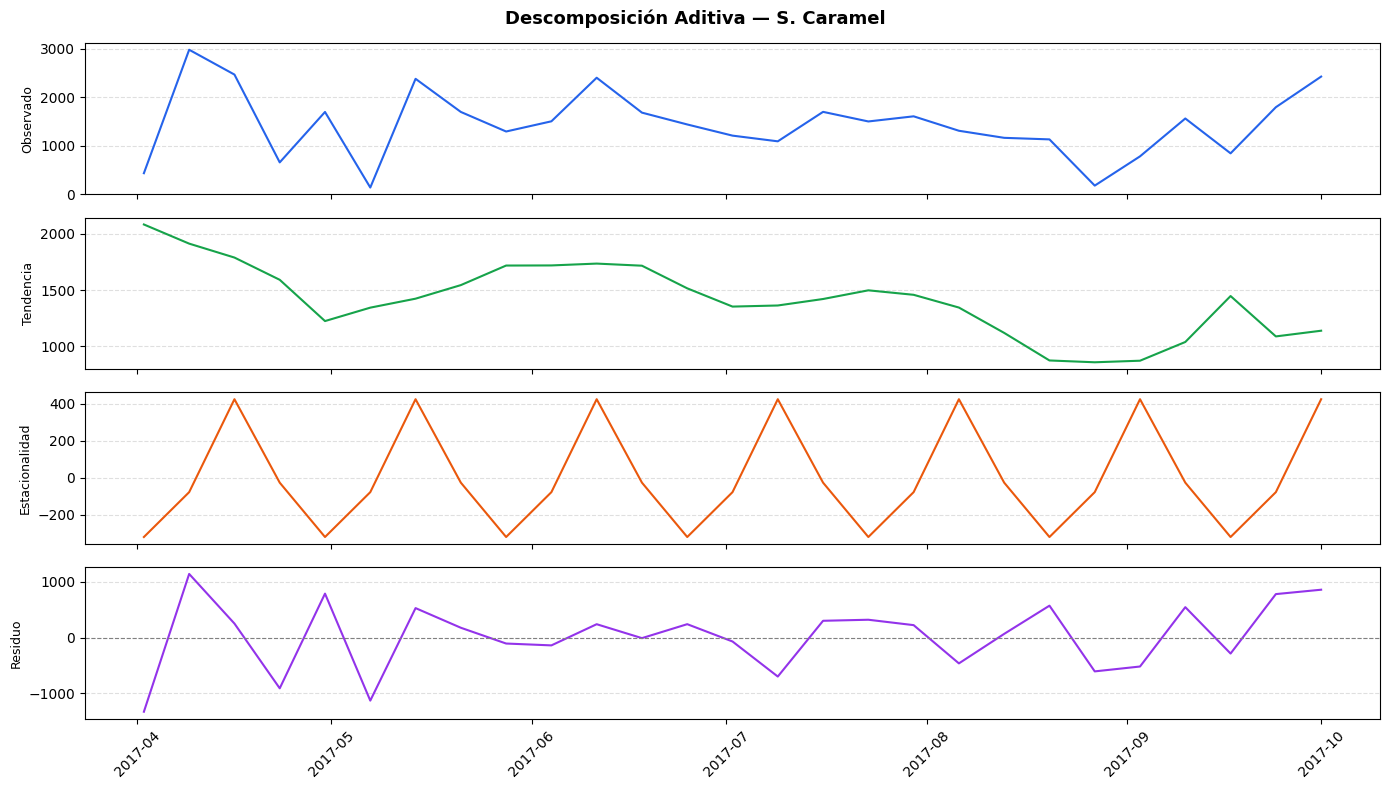

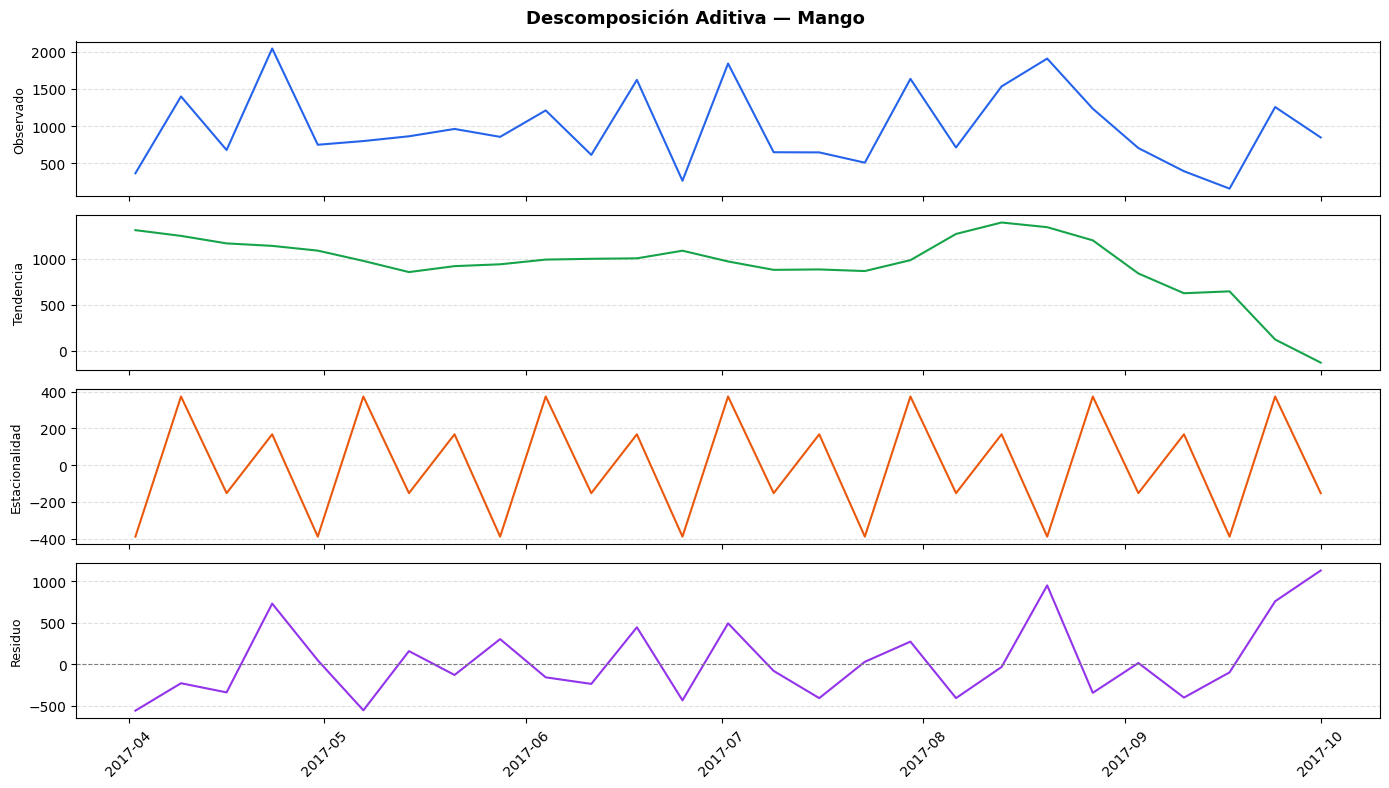

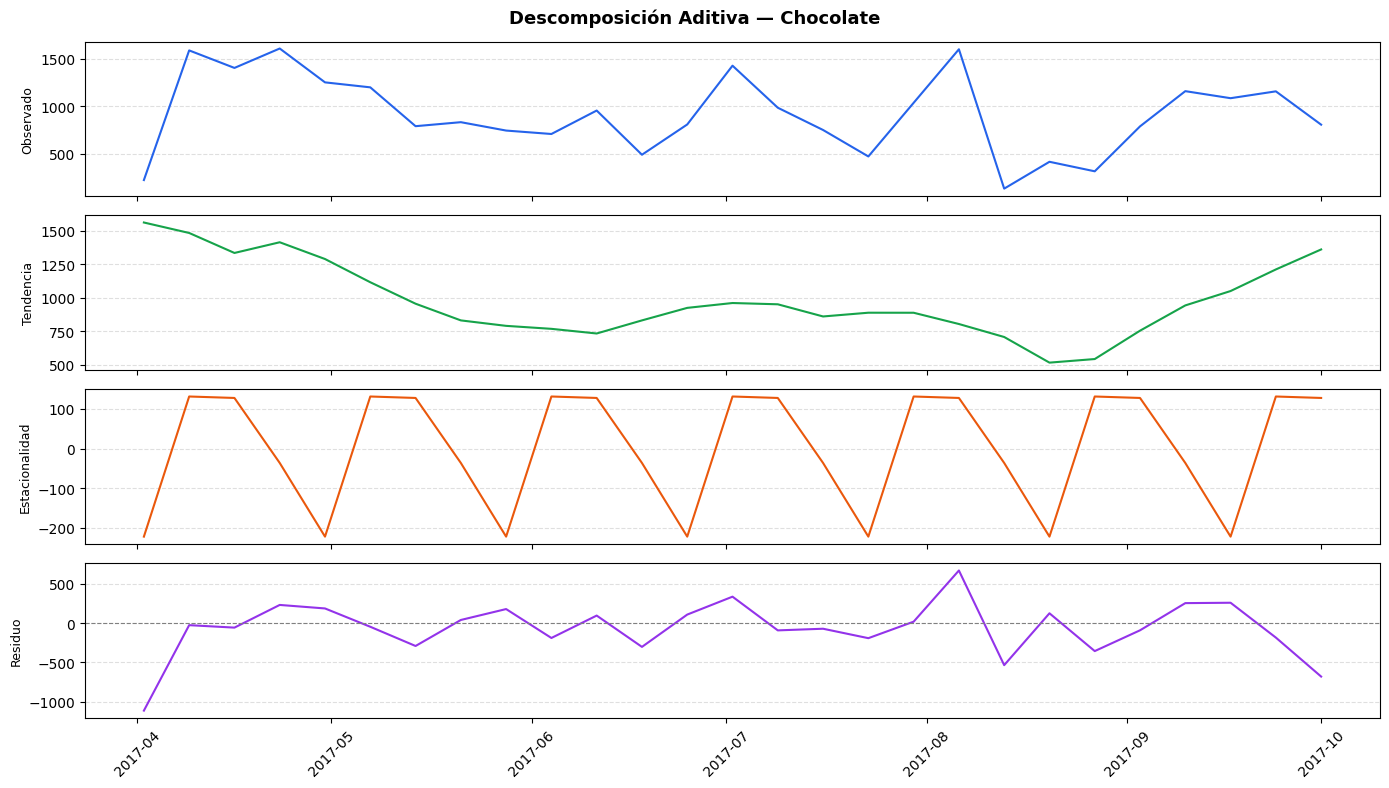

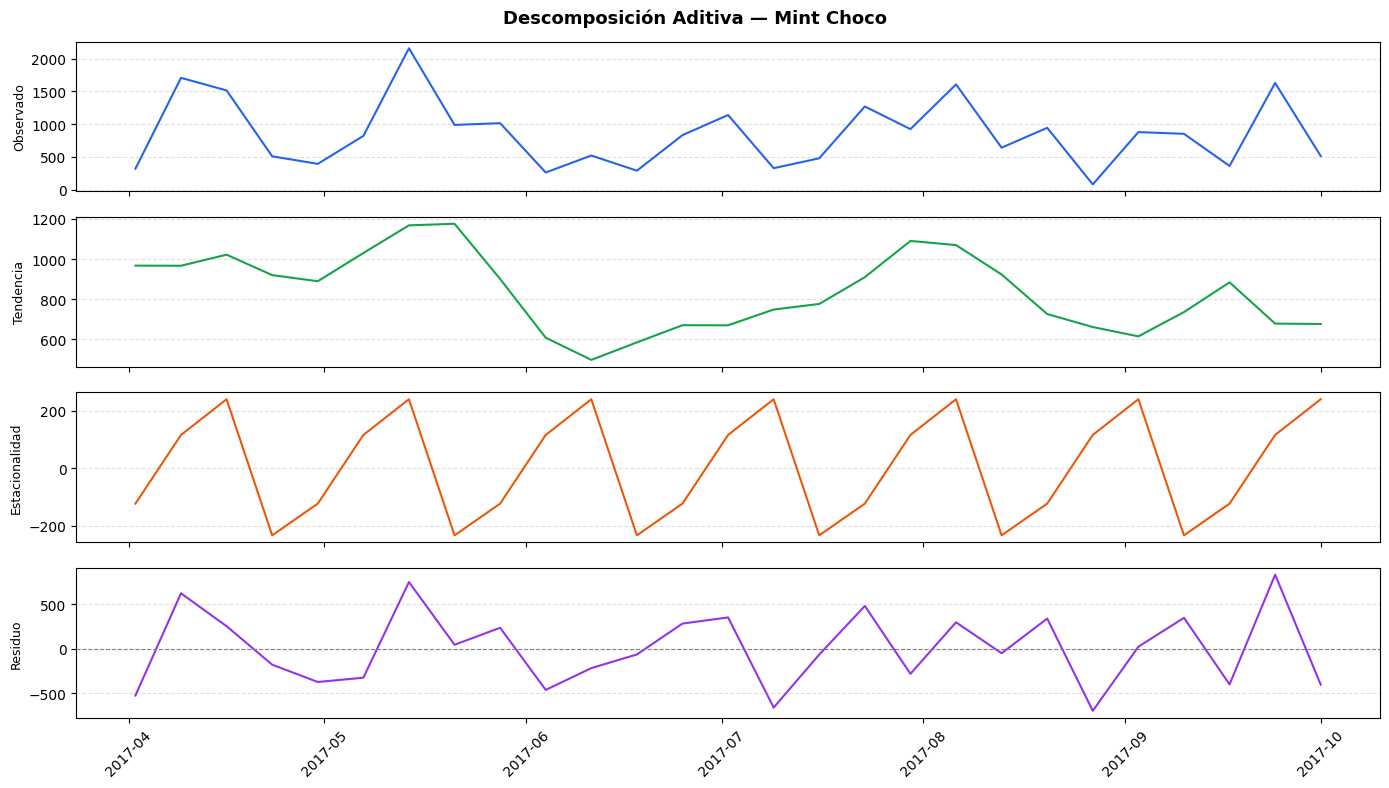

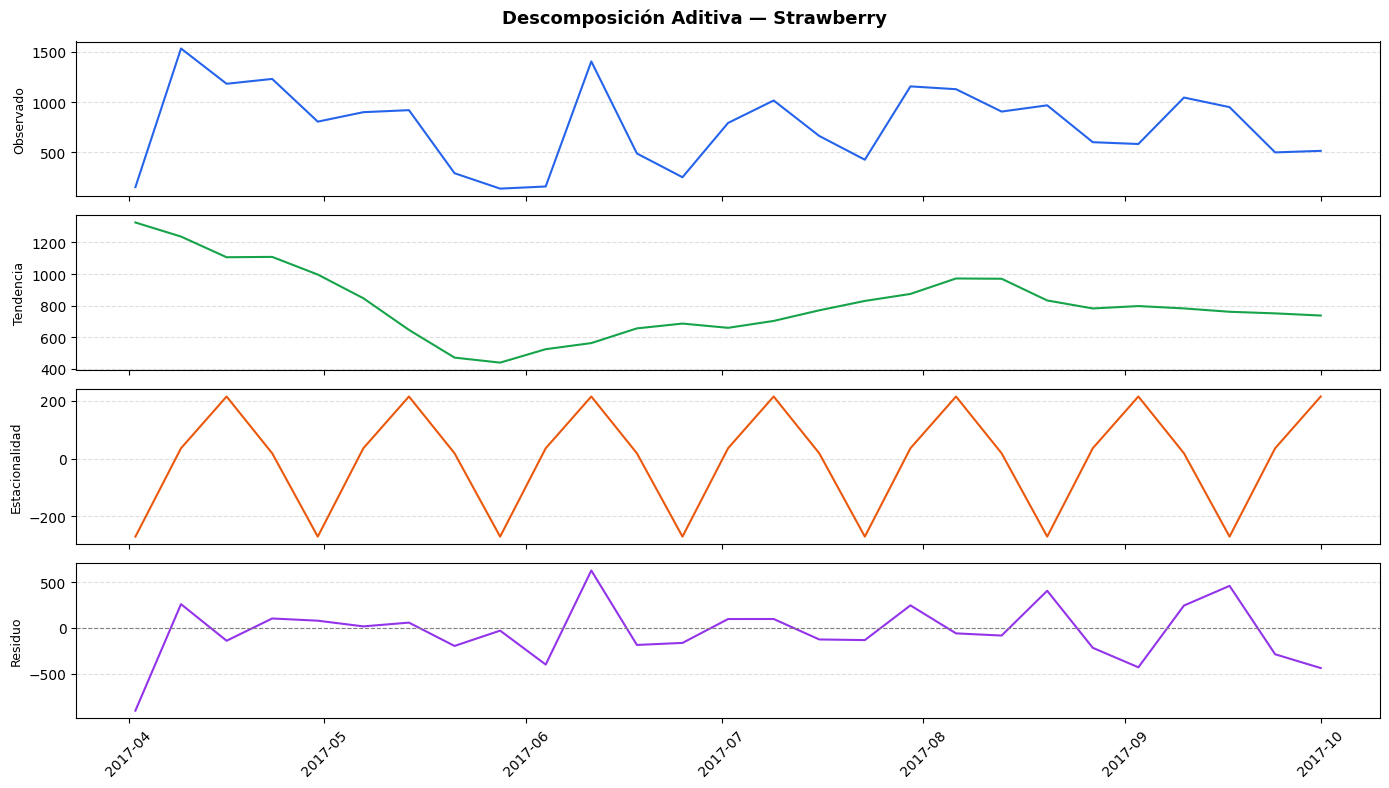

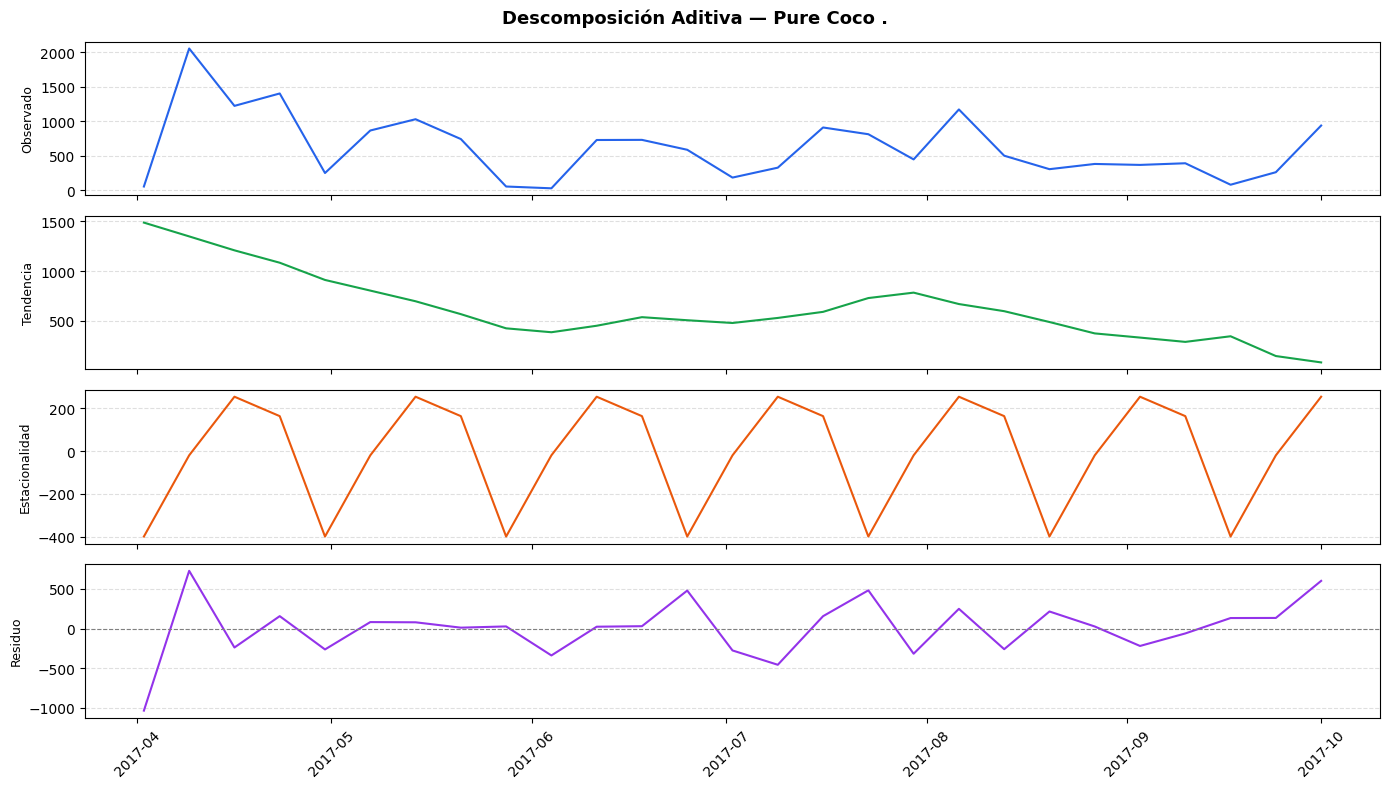

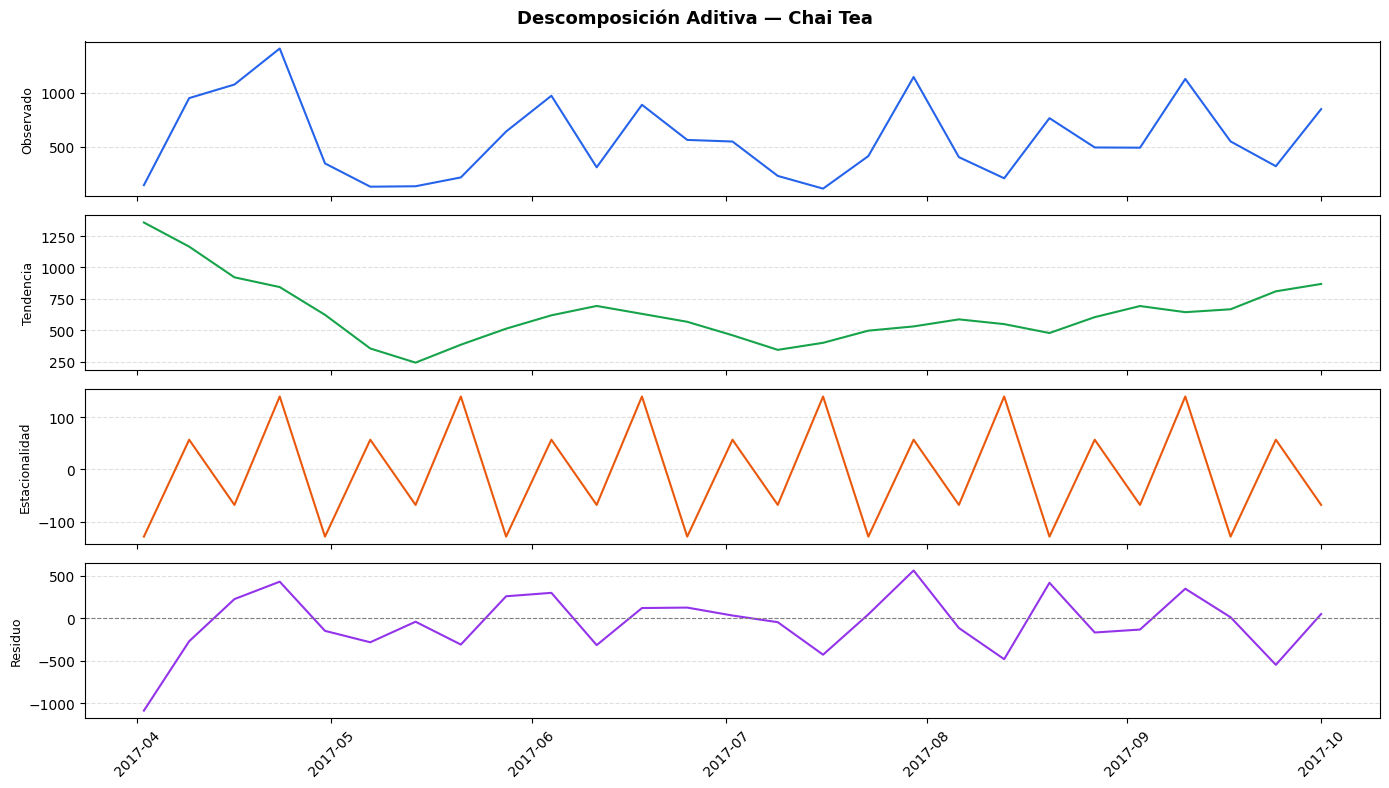

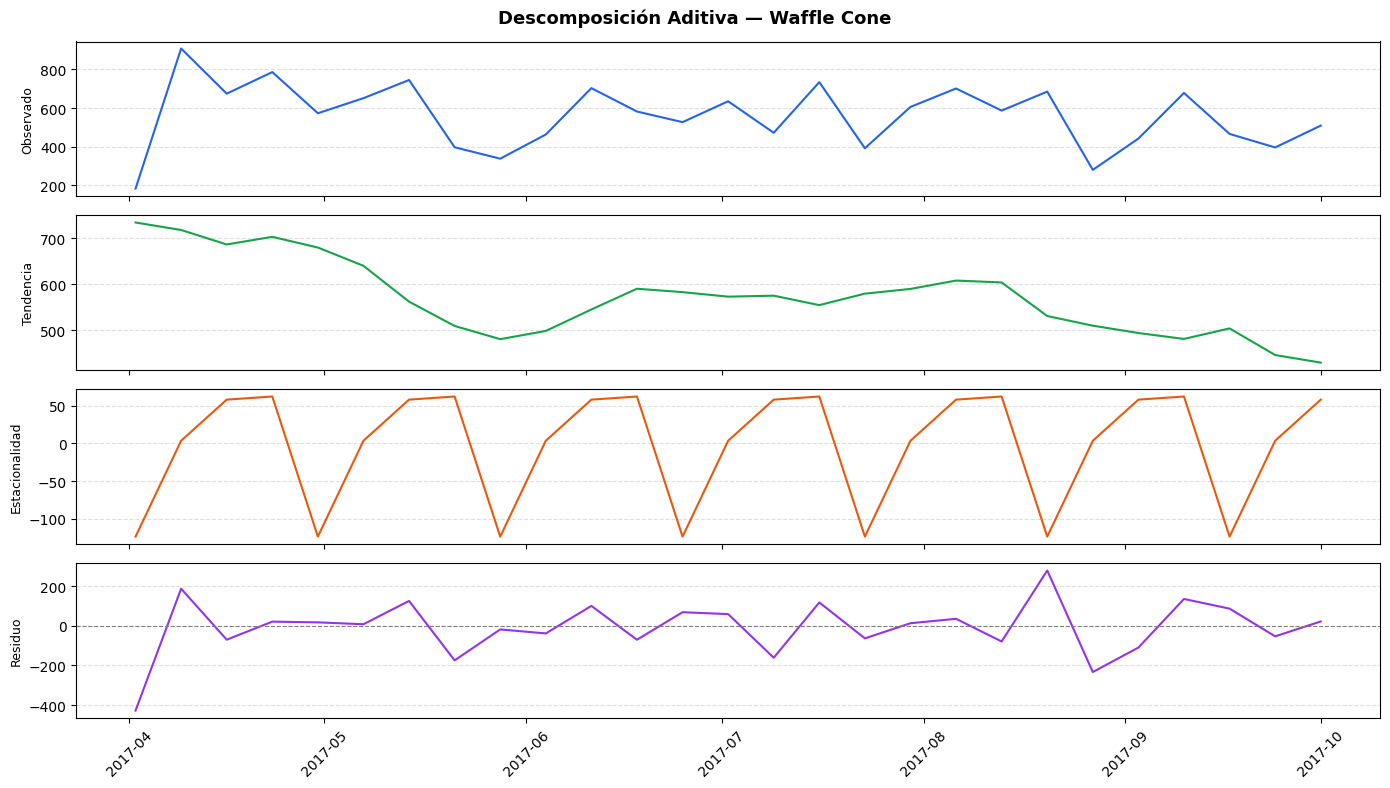

Exception ignored in: <function WeakSet.__init__.<locals>._remove at 0x7bb976504720>
Traceback (most recent call last):
  File "/usr/lib/python3.12/_weakrefset.py", line 39, in _remove
    def _remove(item, selfref=ref(self)):

KeyboardInterrupt: 


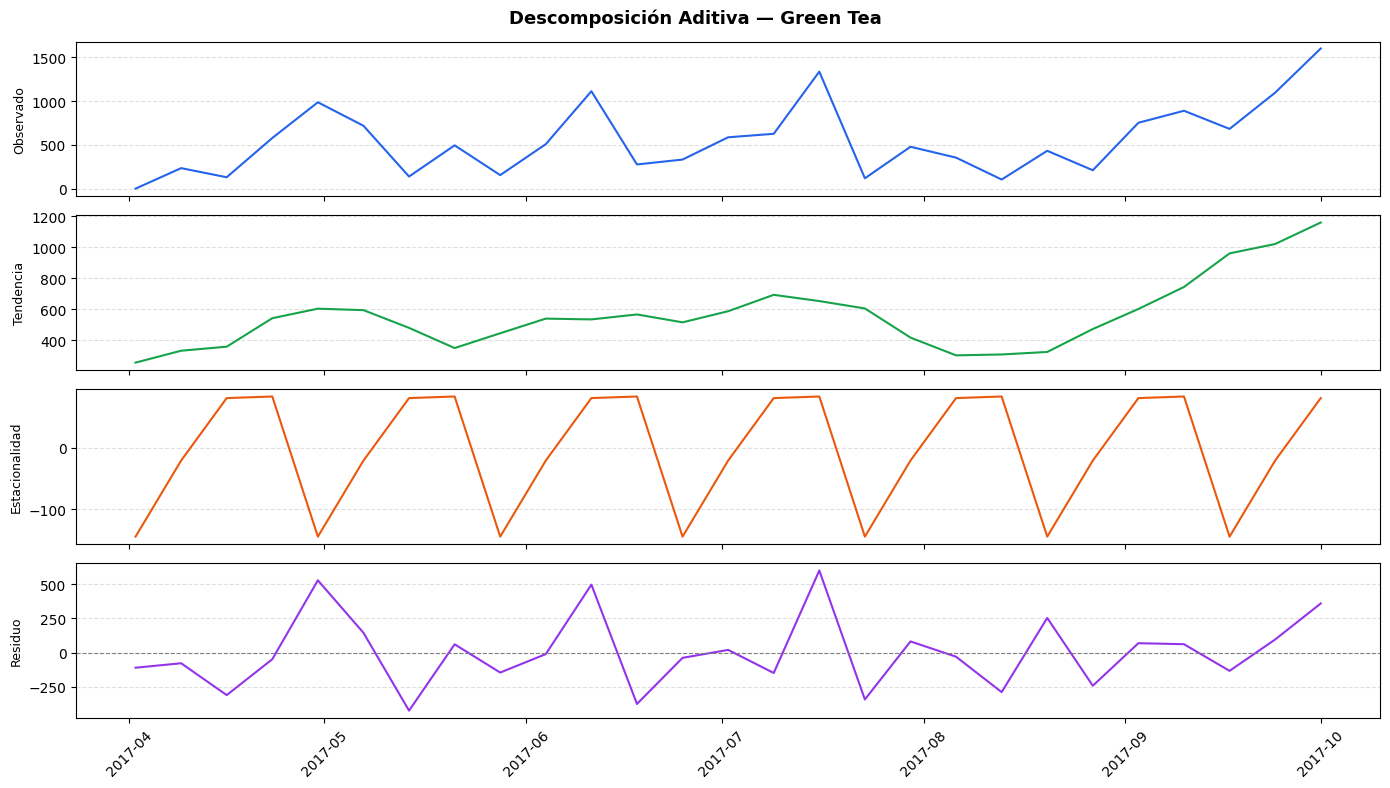

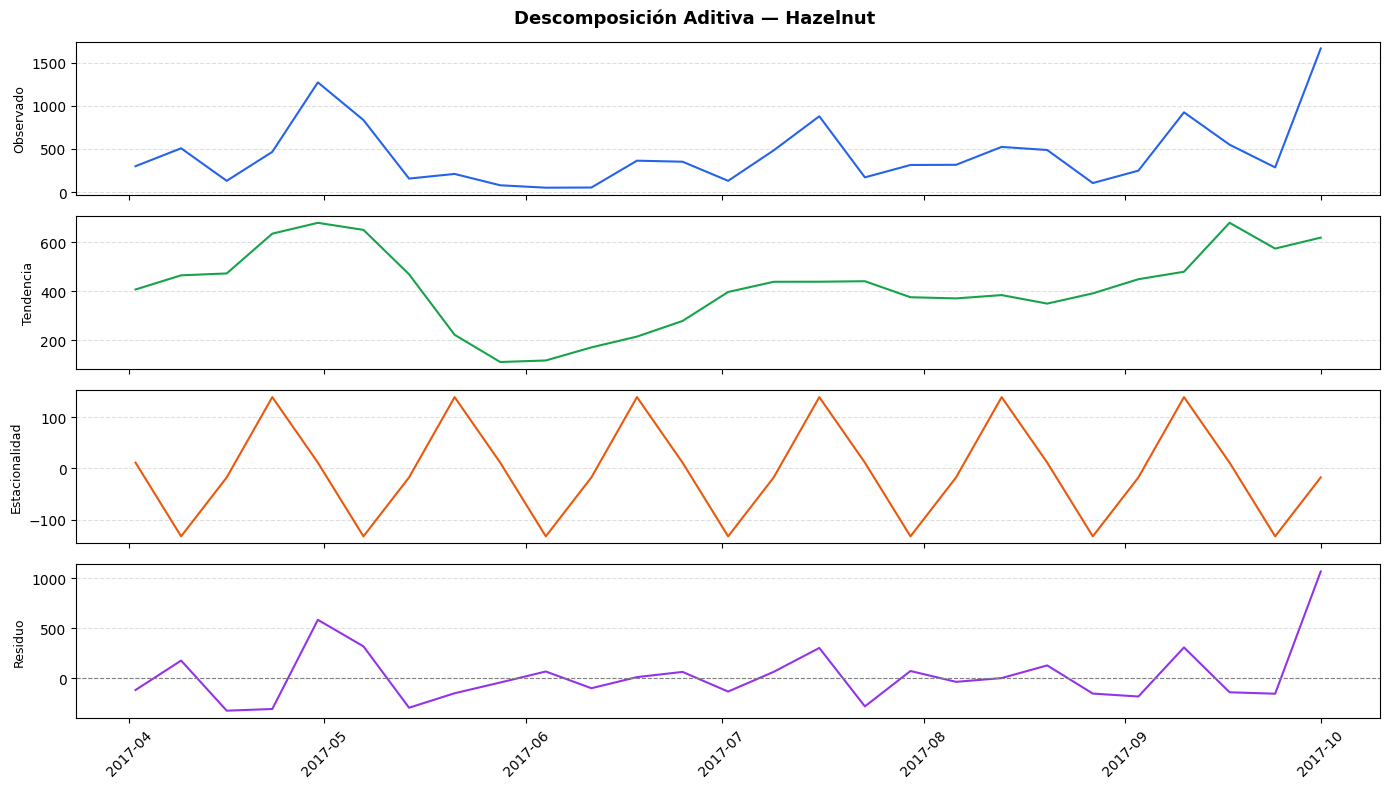

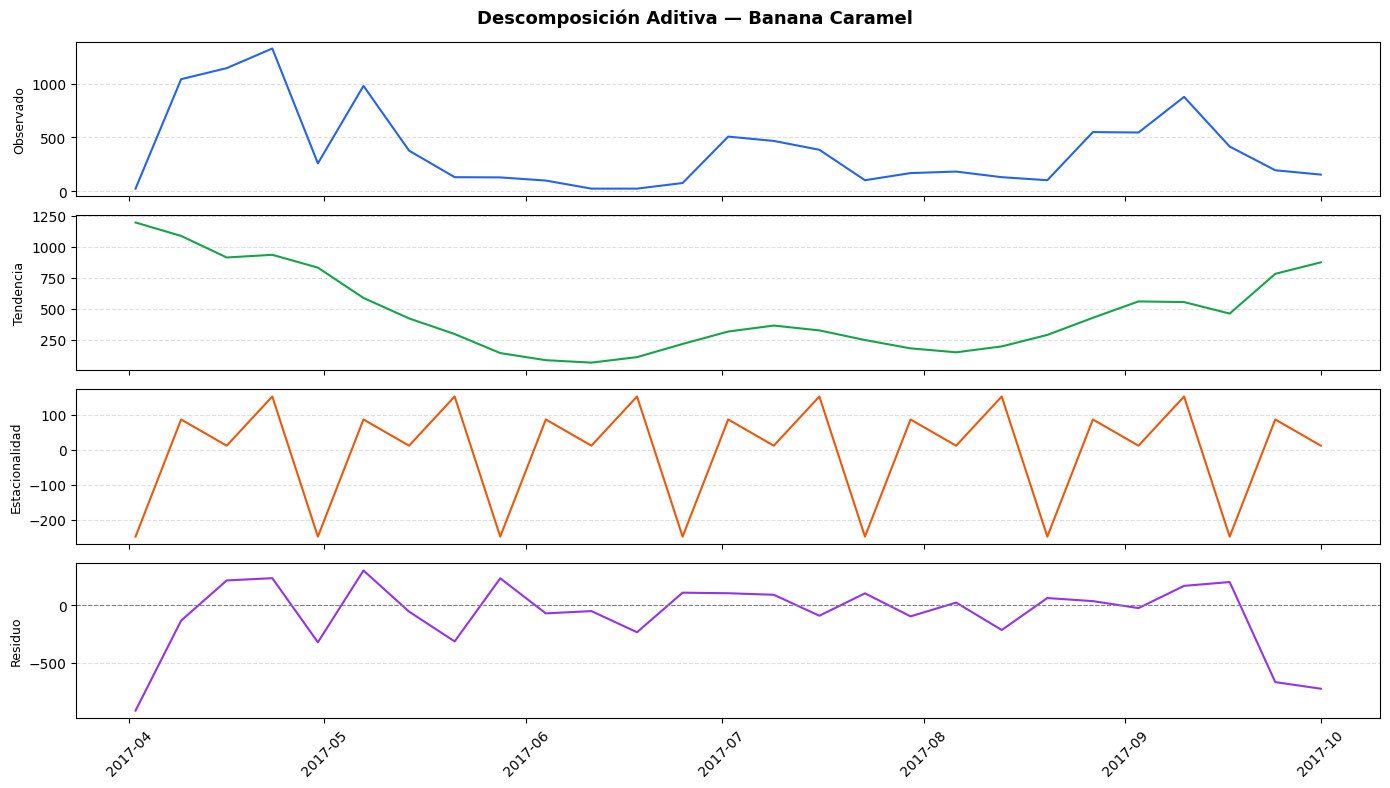

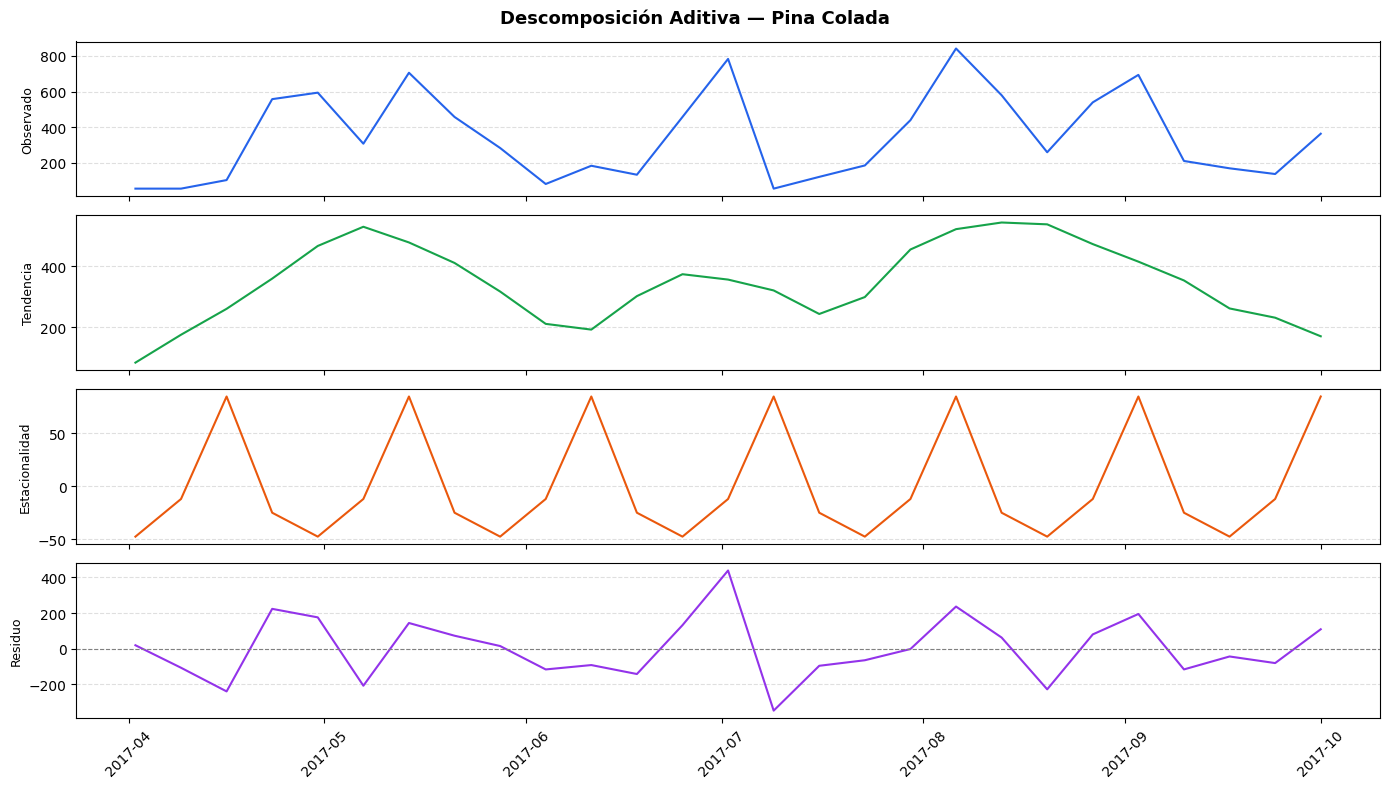

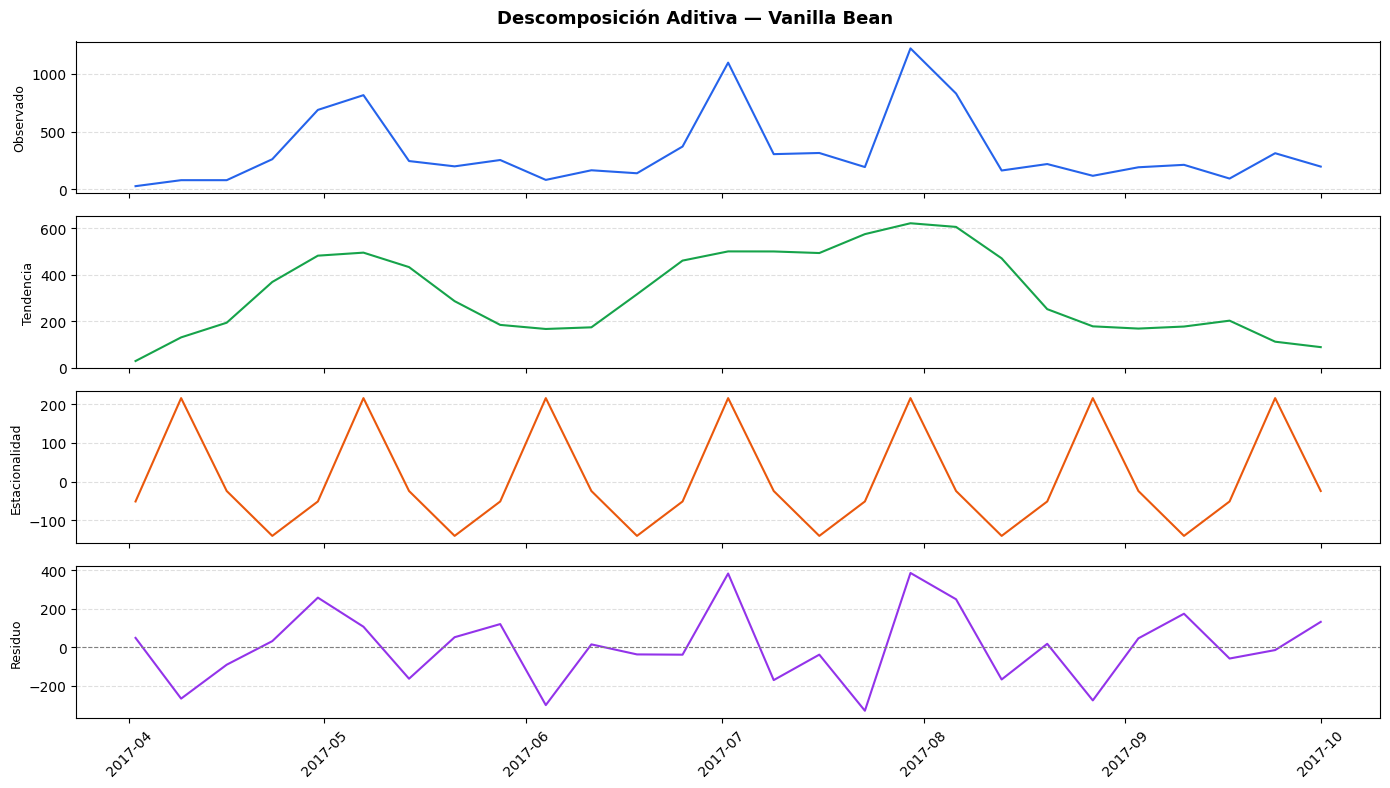

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

data_pivot = (
    data.groupby(['Date_clean', product_col])['Revenue']
    .sum().unstack(product_col).fillna(0)
)

resultados_decomp = {}
for producto in productos_top_80:
    if producto not in data_pivot.columns:
        continue
    try:
        descomp = seasonal_decompose(data_pivot[producto], model='additive', period=4, extrapolate_trend='freq')
        resultados_decomp[producto] = descomp
    except Exception as e:
        print(f'Error en {producto}: {e}')

print(f'\n✅ Descomposición completada para {len(resultados_decomp)} productos.')

for producto, descomp in resultados_decomp.items():
    fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
    fig.suptitle(f'Descomposición Aditiva — {producto}', fontsize=13, fontweight='bold')
    for ax, (serie, label, color) in zip(axes, [
        (descomp.observed,  'Observado',       '#2563eb'),
        (descomp.trend,     'Tendencia',        '#16a34a'),
        (descomp.seasonal,  'Estacionalidad',   '#ea580c'),
        (descomp.resid,     'Residuo',          '#9333ea'),
    ]):
        ax.plot(serie, color=color, linewidth=1.5)
        ax.set_ylabel(label, fontsize=9)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        if label == 'Residuo':
            ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    axes[-1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()


# Punto 2: Modelo base — Media Móvil (MA)

Como modelo base se eligió la **media móvil** por ser uno de los modelos más simples de implementar. El objetivo es contar con un punto de referencia claro que permita medir el aporte real de modelos más avanzados. La ventana óptima se selecciona mediante validación *walk-forward* dentro del conjunto de entrenamiento, garantizando que no hay fuga de información del test.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

revenue_por_producto = (
    data
    .groupby(['Date_clean', 'Product_clean'])['Revenue']
    .sum().reset_index()
    .rename(columns={'Date_clean': 'ds', 'Product_clean': 'producto', 'Revenue': 'y'})
    .sort_values('ds').reset_index(drop=True)
)

productos = sorted(revenue_por_producto['producto'].unique())

print('=' * 60)
print('  Series temporales — Revenue Semanal por Producto')
print('=' * 60)
print(f"  Productos incluidos : {len(productos)}")
print(f"  Período             : {revenue_por_producto['ds'].min().date()} → "
      f"{revenue_por_producto['ds'].max().date()}")
print()
print(f"  {'Producto':<35} {'Semanas':>7}  {'Avg HKD':>10}  {'CV':>6}")
print(f"  {'─'*58}")
for p in productos:
    s  = revenue_por_producto[revenue_por_producto['producto'] == p]
    cv = s['y'].std() / s['y'].mean() * 100
    print(f"  {p:<35} {len(s):>7}  {s['y'].mean():>10,.0f}  {cv:>5.0f}%")


### 2.1 Separación temporal: Train / Test


In [ ]:
HORIZONTE = 4

fechas_ordenadas = sorted(revenue_por_producto['ds'].unique())
fecha_corte      = fechas_ordenadas[-HORIZONTE]

print('=' * 60)
print('  Separación temporal Train / Test')
print('=' * 60)
print(f"  TRAIN : hasta {fechas_ordenadas[-HORIZONTE - 1].strftime('%Y-%m-%d')}  "
      f"({len(fechas_ordenadas) - HORIZONTE} semanas)")
print(f"  TEST  : {fecha_corte.strftime('%Y-%m-%d')} → "
      f"{fechas_ordenadas[-1].strftime('%Y-%m-%d')}  ({HORIZONTE} semanas)")


### 2.2 Función de media móvil con walk-forward CV


In [ ]:
VENTANAS = [2, 3, 4, 5, 6]

def mejor_ventana_ma(y_train, ventanas):
    mejor_w, mejor_mae = None, np.inf
    for w in ventanas:
        if len(y_train) <= w:
            continue
        errores = [abs(y_train[i] - np.mean(y_train[i - w:i])) for i in range(w, len(y_train))]
        mae_w   = np.mean(errores)
        if mae_w < mejor_mae:
            mejor_mae = mae_w
            mejor_w   = w
    return mejor_w, mejor_mae


### 2.3 Métricas del modelo base


In [ ]:
resultados_ma  = []
predicciones   = {}

for producto in productos:
    serie = (revenue_por_producto[revenue_por_producto['producto'] == producto]
             .sort_values('ds').reset_index(drop=True))
    train = serie[serie['ds'] < fecha_corte].reset_index(drop=True)
    test  = serie[serie['ds'] >= fecha_corte].reset_index(drop=True)

    if len(train) < min(VENTANAS) or len(test) < HORIZONTE:
        continue

    w_opt, _   = mejor_ventana_ma(train['y'].values, VENTANAS)
    pred_valor = train['y'].rolling(w_opt).mean().iloc[-1]
    pred       = np.array([pred_valor] * HORIZONTE)

    y_real = test['y'].values[:HORIZONTE]
    mae    = np.mean(np.abs(y_real - pred))
    rmse   = np.sqrt(np.mean((y_real - pred) ** 2))
    mape   = np.mean(np.abs((y_real - pred) / np.where(y_real == 0, 1, y_real))) * 100

    resultados_ma.append({'Producto': producto, 'Ventana MA': w_opt,
                          'MAE_MA': mae, 'RMSE_MA': rmse, 'MAPE_MA': mape})
    predicciones[producto] = {'train': train, 'test': test,
                               'pred_ma': pred, 'w': w_opt, 'mae_ma': mae, 'mape_ma': mape}

df_ma = pd.DataFrame(resultados_ma).sort_values('MAPE_MA').reset_index(drop=True)

print(f"  {'Producto':<35} {'w':>3}  {'MAE (HKD)':>11}  {'MAPE (%)':>9}")
print(f"  {'─'*62}")
for _, row in df_ma.iterrows():
    print(f"  {row['Producto']:<35} {int(row['Ventana MA']):>3}  "
          f"{row['MAE_MA']:>11,.0f}  {row['MAPE_MA']:>8.1f}%")
print(f"  {'─'*62}")
print(f"  {'PROMEDIO':<35}  {'':>3}  "
      f"{df_ma['MAE_MA'].mean():>11,.0f}  {df_ma['MAPE_MA'].mean():>8.1f}%")

metricas_base = df_ma.copy()


### 2.4 Gráfico Train / Test / Predicción Base


In [ ]:
n_cols  = 2
n_rows  = (len(predicciones) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows), constrained_layout=True)
axes = axes.flatten()

for idx, (producto, d) in enumerate(predicciones.items()):
    ax = axes[idx]
    ax.plot(d['train']['ds'], d['train']['y'], marker='o', color='#2563eb', lw=1.8, ms=4, label='Train')
    ax.plot(d['test']['ds'], d['test']['y'], marker='o', color='#16a34a', lw=2, ms=7, label='Test real', zorder=4)
    ax.plot(d['test']['ds'], d['pred_ma'], marker='s', ls='--', color='#f97316', lw=1.8, ms=7,
            label=f"MA({d['w']}) = HKD {d['pred_ma'][0]:,.0f}", zorder=4)
    ax.axvline(d['test']['ds'].iloc[0], color='gray', ls=':', lw=1.3, alpha=0.7, label='Inicio test')
    ax.set_title(f"{producto}\nMA({d['w']}) | MAE={d['mae_ma']:,.0f} | MAPE={d['mape_ma']:.1f}%",
                 fontsize=9, fontweight='bold')
    ax.set_ylabel('Revenue (HKD)', fontsize=8)
    ax.set_xlabel('Semana', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.grid(axis='y', ls='--', alpha=0.4)
    ax.legend(fontsize=7.5, loc='upper left')

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'Punto 2 — Modelo Base MA | Happy Cow | MAPE promedio: {df_ma["MAPE_MA"].mean():.1f}%',
             fontsize=12, fontweight='bold')
plt.show()


# Punto 3: Análisis de estacionariedad — Test ADF

Antes de justificar la elección de los modelos avanzados, es necesario verificar si las series de tiempo son **estacionarias**, es decir, si presentan media, varianza y covarianza constantes a lo largo del tiempo. Este análisis es fundamental para decidir qué modelos son estadísticamente válidos y cuáles presentan limitaciones en cada serie.

Se utiliza el **Test de Dickey-Fuller Aumentado (ADF)**: la hipótesis nula establece que la serie tiene raíz unitaria (es decir, *no* es estacionaria). Si el p-valor es menor que 0.05 se rechaza la hipótesis nula y se concluye que la serie **sí** es estacionaria.


In [ ]:
from statsmodels.tsa.stattools import adfuller

print('=' * 62)
print('  Test ADF — Estacionariedad por producto')
print('=' * 62)
print(f"  {'Producto':<35} {'ADF stat':>10}  {'p-value':>8}  {'¿Estac?':>8}  {'d':>4}")
print(f"  {'─'*62}")

adf_resultados = {}
for producto in productos:
    serie = (revenue_por_producto[revenue_por_producto['producto'] == producto]
             .sort_values('ds').reset_index(drop=True))
    train = serie[serie['ds'] < fecha_corte].reset_index(drop=True)
    if len(train) < 8:
        continue
    stat, pval, *_ = adfuller(train['y'].values, autolag='AIC')
    estac = pval < 0.05
    adf_resultados[producto] = {'stat': stat, 'pval': pval, 'estac': estac, 'd': 0 if estac else 1}
    print(f"  {producto:<35} {stat:>10.3f}  {pval:>8.4f}  "
          f"{'✓' if estac else '✗':>8}  {'0' if estac else '1':>4}")

n_estac = sum(1 for v in adf_resultados.values() if v['estac'])
no_estac = [k for k, v in adf_resultados.items() if not v['estac']]
print(f"\n  Estacionarias: {n_estac}/{len(adf_resultados)} productos")
print(f"  No estacionarias: {no_estac}")


# Punto 4: Justificación de los modelos avanzados

A partir del análisis de estacionariedad y de las limitaciones identificadas en el modelo base (MA), se seleccionaron cinco modelos avanzados para intentar mejorar el forecasting. A continuación se justifica cada elección.

## Contexto del problema

El modelo base (MA) mostró un MAPE promedio elevado, con productos como Mango (243 %), Pure Coco (192 %) y Piña Colada (200 %) con predicciones muy imprecisas. Las razones estructurales de esta limitación son:

1. **La MA asume que el futuro es igual al promedio del pasado reciente**: no captura tendencia ni estacionalidad.
2. **8 de 13 series son estacionarias** según el ADF, lo que es positivo para modelos ARIMA, pero las 4 no estacionarias (Banana Caramel, Chocolate, Hazelnut, Waffle Cone) requieren diferenciación.
3. **Las series son cortas** (~27 semanas de entrenamiento), lo que limita modelos con muchos parámetros.
4. **Existen variables externas** (promociones) que podrían explicar parte de la variabilidad residual.

---

## Modelo 1 — SARIMA *(Seasonal AutoRegressive Integrated Moving Average)*

**¿Por qué?** El análisis ADF mostró que la mayoría de las series son estacionarias (d=0), y las que no lo son requieren una sola diferencia (d=1). SARIMA captura explícitamente tres dimensiones que la MA ignora por completo:
- **Componente AR (p):** el revenue de esta semana depende de semanas anteriores.
- **Componente MA (q):** los errores pasados ayudan a corregir la predicción actual.
- **Componente estacional (P, D, Q, m=4):** patrón que se repite cada ~4 semanas (mensual aproximado).

Para los 4 productos no estacionarios (Banana Caramel, Chocolate, Hazelnut, Waffle Cone) se espera que la diferenciación d=1 y/o D=1 estabilice la media antes del ajuste, aunque con series cortas los resultados tienen validez estadística limitada.

**Limitación:** SARIMA no incorpora variables externas como las promociones.

---

## Modelo 2 — SARIMAX *(SARIMA + variables eXógenas)*

**¿Por qué?** La descomposición aditiva mostró residuos grandes al inicio y al final del periodo, lo que sugiere que hay factores externos no capturados. Se identificó que las promociones (descuentos, vouchers, eventos) tienen impacto directo sobre el revenue. SARIMAX extiende a SARIMA incorporando la **intensidad promocional semanal** (suma absoluta de descuentos por semana) como variable exógena.

**Limitación:** La exógena futura debe estimarse o suponerse constante al momento de predecir. Si el efecto promocional no es sistemático, el modelo puede sobreajustarse.

---

## Modelo 3 — ETS *(Error, Trend, Seasonality — Holt-Winters)*

**¿Por qué?** ETS es especialmente robusto para **series cortas** (~27 semanas de entrenamiento), que es precisamente nuestra restricción principal. A diferencia de SARIMA, no requiere que la serie sea estacionaria y su estimación es más estable con pocos datos. Prueba automáticamente múltiples configuraciones (tendencia aditiva/multiplicativa, amortiguada o no, estacionalidad aditiva/multiplicativa) y selecciona la mejor por AIC. Para los 4 productos no estacionarios (que presentan tendencia), ETS puede modelarla directamente sin necesidad de diferenciación.

**Limitación:** No incorpora variables exógenas.

---

## Modelo 4 — Prophet *(Facebook/Meta)*

**¿Por qué?** Prophet descompone la serie en tendencia + estacionalidad + festivos/eventos de forma automática. Es tolerante a series irregulares, valores atípicos y cambios de tendencia (changepoints), que son características observadas en varias series del dataset (S. Caramel, por ejemplo, muestra tres ciclos descendentes en la tendencia). Prophet también puede incorporar las variables exógenas como regresores adicionales. Además, **no requiere estacionariedad**, lo que lo hace válido para todos los productos incluyendo los 4 no estacionarios.

**Limitación:** Con series muy cortas (~27 puntos), la detección de changepoints puede ser inestable y sobreajustar la tendencia.

---

## Modelo 5 — LightGBM con features de lag

**¿Por qué?** Los modelos estadísticos asumen relaciones lineales entre rezagos y el valor futuro. LightGBM es un modelo de gradient boosting que puede capturar **relaciones no lineales** entre las ventas pasadas y las ventas futuras. Construye features de lag (semanas anteriores), estadísticas rodantes (media, desviación) y todas las variables exógenas disponibles. No asume ninguna estructura temporal específica ni requiere estacionariedad. Al trabajar en escala logarítmica (log1p), se reduce el impacto de los valores extremos.

**Limitación:** Con series de ~23 puntos de entrenamiento, el modelo tiene muy pocos ejemplos para generalizar, lo que puede llevar a sobreajuste. Su ventaja real se manifiesta con más datos.

---

> **Resumen:** La combinación de estos 5 modelos cubre el espectro de aproximaciones posibles: estadística clásica (SARIMA, SARIMAX, ETS), descomposición bayesiana (Prophet) y aprendizaje automático (LightGBM). Algunos son más adecuados para series estacionarias, otros para series cortas o con variables externas, lo que nos permitirá identificar qué enfoque funciona mejor para cada producto.


# Punto 5: Instalación de dependencias adicionales


In [ ]:
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

try:
    from prophet import Prophet
    print('Prophet ya instalado.')
except ImportError:
    print('Instalando Prophet...')
    pip_install('prophet')
    from prophet import Prophet

try:
    import lightgbm as lgb
    print('LightGBM ya instalado.')
except ImportError:
    print('Instalando LightGBM...')
    pip_install('lightgbm')
    import lightgbm as lgb

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product as iterproduct
print('Todas las dependencias listas.')


# Punto 6: Funciones auxiliares compartidas


In [ ]:
# ── Métricas ──────────────────────────────────────────────────────────────
def calcular_metricas(y_real, y_pred):
    y_real = np.array(y_real, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mae    = np.mean(np.abs(y_real - y_pred))
    rmse   = np.sqrt(np.mean((y_real - y_pred) ** 2))
    mask   = y_real != 0
    mape   = np.mean(np.abs((y_real[mask] - y_pred[mask]) / y_real[mask])) * 100 if mask.sum() > 0 else np.nan
    return mae, rmse, mape

# ── Filtro de predicciones válidas ────────────────────────────────────────
def predicciones_validas(pred, y_train):
    pred = np.array(pred, dtype=float)
    if np.any(~np.isfinite(pred)) or np.any(pred < 0):
        return False
    max_train = max(float(np.max(y_train)), 1.0)
    return not np.any(pred > 5 * max_train)

# ── Variable exógena: intensidad promocional semanal ────────────────────
promociones['descuento_abs'] = promociones['Revenue'].abs()
promociones['Date_clean']    = pd.to_datetime(promociones['Date_clean'], errors='coerce')

exog_promo = (
    promociones
    .groupby(pd.Grouper(key='Date_clean', freq='W'))['descuento_abs']
    .sum().reset_index()
    .rename(columns={'Date_clean': 'ds', 'descuento_abs': 'promo'})
)

def alinear_exog(serie_ds, exog_df):
    merged = pd.merge(pd.DataFrame({'ds': serie_ds}), exog_df, on='ds', how='left').fillna(0)
    return merged['promo'].values.reshape(-1, 1)

print('Funciones auxiliares definidas.')
print(f'Semanas con dato de promo: {len(exog_promo)}  |  Promo promedio: HKD {exog_promo["promo"].mean():,.0f}/sem')


# Punto 7: Modelo 1 — SARIMA


In [ ]:
M = 4  # periodo estacional: ~4 semanas (mensual)

def grid_search_sarima(y_train_log, m=4):
    mejor_aic    = np.inf
    mejor_orden  = None
    mejor_ord_s  = None
    mejor_modelo = None

    for p, d, q in iterproduct(range(3), range(2), range(3)):
        for P, D, Q in iterproduct(range(2), range(2), range(2)):
            n_params = p + q + P + Q + d + D
            if n_params == 0 or n_params > len(y_train_log) // 3:
                continue
            try:
                mod    = SARIMAX(y_train_log, order=(p, d, q),
                                 seasonal_order=(P, D, Q, m),
                                 enforce_stationarity=False, enforce_invertibility=False)
                fitted = mod.fit(disp=False, maxiter=200)
                if fitted.aic < mejor_aic:
                    mejor_aic    = fitted.aic
                    mejor_orden  = (p, d, q)
                    mejor_ord_s  = (P, D, Q, m)
                    mejor_modelo = fitted
            except Exception:
                continue
    return mejor_orden, mejor_ord_s, mejor_modelo


resultados_sarima = []
print(f"  {'Producto':<35} {'Orden':>14} {'Estacional':>14}  {'MAE':>9}  {'MAPE':>7}")
print(f"  {'─'*75}")

for producto in productos:
    serie = (revenue_por_producto[revenue_por_producto['producto'] == producto]
             .sort_values('ds').reset_index(drop=True))
    train = serie[serie['ds'] < fecha_corte].reset_index(drop=True)
    test  = serie[serie['ds'] >= fecha_corte].reset_index(drop=True)

    if len(train) < 8 or len(test) < HORIZONTE:
        continue

    y_train     = train['y'].values.astype(float)
    y_train_log = np.log1p(y_train)
    y_test      = test['y'].values[:HORIZONTE].astype(float)

    orden, ord_s, modelo = grid_search_sarima(y_train_log, m=M)

    if modelo is None:
        resultados_sarima.append({'Producto': producto, 'MAE_SARIMA': np.nan,
                                   'RMSE_SARIMA': np.nan, 'MAPE_SARIMA': np.nan})
        continue

    pred_log  = modelo.forecast(steps=HORIZONTE)
    pred      = np.maximum(np.expm1(pred_log), 0)

    if not predicciones_validas(pred, y_train):
        pred = np.full(HORIZONTE, np.nan)

    mae, rmse, mape = calcular_metricas(y_test, pred) if np.all(np.isfinite(pred)) else (np.nan, np.nan, np.nan)

    resultados_sarima.append({'Producto': producto, 'Orden_SARIMA': str(orden),
                               'Estacional_SARIMA': str(ord_s),
                               'MAE_SARIMA': mae, 'RMSE_SARIMA': rmse, 'MAPE_SARIMA': mape})
    predicciones[producto]['pred_sarima'] = pred

    print(f"  {producto:<35} {str(orden):>14} {str(ord_s):>14}  {mae:>9,.0f}  {mape:>6.1f}%")

df_sarima = pd.DataFrame(resultados_sarima)


# Punto 8: Modelo 2 — SARIMAX


In [ ]:
def grid_search_sarimax(y_train_log, exog_train, m=4):
    mejor_aic    = np.inf
    mejor_orden  = None
    mejor_ord_s  = None
    mejor_modelo = None

    for p, d, q in iterproduct(range(3), range(2), range(3)):
        for P, D, Q in iterproduct(range(2), range(2), range(2)):
            n_params = p + q + P + Q + d + D + 1  # +1 exógena
            if n_params == 0 or n_params > len(y_train_log) // 3:
                continue
            try:
                mod    = SARIMAX(y_train_log, exog=exog_train,
                                 order=(p, d, q), seasonal_order=(P, D, Q, m),
                                 enforce_stationarity=False, enforce_invertibility=False)
                fitted = mod.fit(disp=False, maxiter=200)
                if fitted.aic < mejor_aic:
                    mejor_aic    = fitted.aic
                    mejor_orden  = (p, d, q)
                    mejor_ord_s  = (P, D, Q, m)
                    mejor_modelo = fitted
            except Exception:
                continue
    return mejor_orden, mejor_ord_s, mejor_modelo


resultados_sarimax = []
print(f"  {'Producto':<35} {'Orden':>14} {'Estacional':>14}  {'MAE':>9}  {'MAPE':>7}")
print(f"  {'─'*75}")

for producto in productos:
    serie = (revenue_por_producto[revenue_por_producto['producto'] == producto]
             .sort_values('ds').reset_index(drop=True))
    train = serie[serie['ds'] < fecha_corte].reset_index(drop=True)
    test  = serie[serie['ds'] >= fecha_corte].reset_index(drop=True)

    if len(train) < 8 or len(test) < HORIZONTE:
        continue

    y_train     = train['y'].values.astype(float)
    y_train_log = np.log1p(y_train)
    y_test      = test['y'].values[:HORIZONTE].astype(float)

    exog_train_arr = alinear_exog(train['ds'], exog_promo)
    exog_test_arr  = alinear_exog(test['ds'][:HORIZONTE], exog_promo)

    orden, ord_s, modelo = grid_search_sarimax(y_train_log, exog_train_arr, m=M)

    if modelo is None:
        resultados_sarimax.append({'Producto': producto, 'MAE_SARIMAX': np.nan,
                                    'RMSE_SARIMAX': np.nan, 'MAPE_SARIMAX': np.nan})
        continue

    try:
        fc_res    = modelo.get_forecast(steps=HORIZONTE, exog=exog_test_arr)
        pred      = np.maximum(fc_res.predicted_mean, 0)
        ic        = fc_res.conf_int(alpha=0.05)
        ic_lower  = np.maximum(ic.iloc[:, 0].values if hasattr(ic, 'iloc') else ic[:, 0], 0)
        ic_upper  = ic.iloc[:, 1].values if hasattr(ic, 'iloc') else ic[:, 1]
    except Exception:
        pred     = np.full(HORIZONTE, np.nan)
        ic_lower = ic_upper = pred.copy()

    if not predicciones_validas(pred, y_train):
        pred = np.full(HORIZONTE, np.nan)

    mae, rmse, mape = calcular_metricas(y_test, pred) if np.all(np.isfinite(pred)) else (np.nan, np.nan, np.nan)

    resultados_sarimax.append({'Producto': producto, 'Orden_SARIMAX': str(orden),
                                'Estacional_SARIMAX': str(ord_s),
                                'MAE_SARIMAX': mae, 'RMSE_SARIMAX': rmse, 'MAPE_SARIMAX': mape})
    predicciones[producto]['pred_sarimax'] = pred
    predicciones[producto]['ic_lower']     = ic_lower
    predicciones[producto]['ic_upper']     = ic_upper

    print(f"  {producto:<35} {str(orden):>14} {str(ord_s):>14}  {mae:>9,.0f}  {mape:>6.1f}%")

df_sarimax_r = pd.DataFrame(resultados_sarimax)


# Punto 9: Modelo 3 — ETS (Holt-Winters)


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

def entrenar_ets(y_train, horizonte=4, m=4):
    y      = np.array(y_train, dtype=float)
    y_safe = np.where(y == 0, 0.01, y)

    if len(y) >= 2 * m + 2:
        configs = [
            dict(trend='add', damped_trend=False, seasonal='add', seasonal_periods=m),
            dict(trend='add', damped_trend=True,  seasonal='add', seasonal_periods=m),
            dict(trend='add', damped_trend=False, seasonal='mul', seasonal_periods=m),
            dict(trend='add', damped_trend=True,  seasonal='mul', seasonal_periods=m),
            dict(trend=None,  damped_trend=False, seasonal='add', seasonal_periods=m),
            dict(trend=None,  damped_trend=False, seasonal='mul', seasonal_periods=m),
        ]
    else:
        configs = [
            dict(trend='add', damped_trend=True,  seasonal=None),
            dict(trend='add', damped_trend=False, seasonal=None),
            dict(trend=None,  damped_trend=False, seasonal=None),
        ]

    mejor_aic    = np.inf
    mejor_modelo = None

    for cfg in configs:
        try:
            use_mul = cfg.get('seasonal') == 'mul'
            y_input = y_safe if use_mul else y
            mod     = ExponentialSmoothing(y_input, **cfg)
            fit     = mod.fit(optimized=True, remove_bias=True)
            if np.isfinite(fit.aic) and fit.aic < mejor_aic:
                mejor_aic    = fit.aic
                mejor_modelo = fit
        except Exception:
            continue

    if mejor_modelo is None:
        return None
    try:
        return np.maximum(mejor_modelo.forecast(horizonte), 0)
    except Exception:
        return None


resultados_ets = []
print(f"  {'Producto':<35}  {'MAE':>9}  {'MAPE':>7}")
print(f"  {'─'*55}")

for producto in productos:
    serie = (revenue_por_producto[revenue_por_producto['producto'] == producto]
             .sort_values('ds').reset_index(drop=True))
    train = serie[serie['ds'] < fecha_corte].reset_index(drop=True)
    test  = serie[serie['ds'] >= fecha_corte].reset_index(drop=True)

    if len(train) < 8 or len(test) < HORIZONTE:
        continue

    y_train = train['y'].values.astype(float)
    y_test  = test['y'].values[:HORIZONTE].astype(float)

    pred = entrenar_ets(y_train, horizonte=HORIZONTE, m=M)

    if pred is not None and predicciones_validas(pred, y_train):
        mae, rmse, mape = calcular_metricas(y_test, pred)
    else:
        pred = np.full(HORIZONTE, np.nan)
        mae = rmse = mape = np.nan

    resultados_ets.append({'Producto': producto, 'MAE_ETS': mae, 'RMSE_ETS': rmse, 'MAPE_ETS': mape})
    predicciones[producto]['pred_ets'] = pred
    print(f"  {producto:<35}  {mae:>9,.0f}  {mape:>6.1f}%")

df_ets = pd.DataFrame(resultados_ets)


# Punto 10: Modelo 4 — Prophet


In [ ]:
from prophet import Prophet

def entrenar_prophet(train_df, exog_promo_df, horizonte=4):
    df_p = train_df[['ds', 'y']].copy()
    df_p['y'] = df_p['y'].astype(float)

    # Añadir intensidad promocional como regresor
    promo_arr = alinear_exog(df_p['ds'], exog_promo_df).flatten()
    df_p['promo'] = promo_arr
    promo_std = df_p['promo'].std()

    m = Prophet(
        weekly_seasonality=True,
        yearly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='additive',
        changepoint_prior_scale=0.05,
        interval_width=0.80
    )
    if promo_std > 0:
        m.add_regressor('promo', mode='additive')

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        try:
            m.fit(df_p)
        except Exception:
            return None

    future = m.make_future_dataframe(periods=horizonte, freq='W').tail(horizonte).reset_index(drop=True)
    if promo_std > 0:
        future['promo'] = float(df_p['promo'].mean())

    try:
        return np.maximum(m.predict(future)['yhat'].values, 0)
    except Exception:
        return None


resultados_prophet = []
print(f"  {'Producto':<35}  {'MAE':>9}  {'MAPE':>7}")
print(f"  {'─'*55}")

for producto in productos:
    serie = (revenue_por_producto[revenue_por_producto['producto'] == producto]
             .sort_values('ds').reset_index(drop=True))
    train = serie[serie['ds'] < fecha_corte].reset_index(drop=True)
    test  = serie[serie['ds'] >= fecha_corte].reset_index(drop=True)

    if len(train) < 8 or len(test) < HORIZONTE:
        continue

    y_train = train['y'].values.astype(float)
    y_test  = test['y'].values[:HORIZONTE].astype(float)

    pred = entrenar_prophet(train, exog_promo, horizonte=HORIZONTE)

    if pred is not None and predicciones_validas(pred, y_train):
        mae, rmse, mape = calcular_metricas(y_test, pred)
    else:
        pred = np.full(HORIZONTE, np.nan)
        mae = rmse = mape = np.nan

    resultados_prophet.append({'Producto': producto, 'MAE_Prophet': mae, 'RMSE_Prophet': rmse, 'MAPE_Prophet': mape})
    predicciones[producto]['pred_prophet'] = pred
    print(f"  {producto:<35}  {mae:>9,.0f}  {mape:>6.1f}%")

df_prophet = pd.DataFrame(resultados_prophet)


# Punto 11: Modelo 5 — LightGBM con features de lag


In [ ]:
import lightgbm as lgb

def construir_features(serie_df, exog_promo_df, lags=[1, 2, 3, 4], horizonte=4):
    df_f = serie_df.copy().reset_index(drop=True)
    # Añadir promo
    df_f['promo'] = alinear_exog(df_f['ds'], exog_promo_df).flatten()

    for lag in lags:
        df_f[f'lag_{lag}'] = df_f['y'].shift(lag)

    df_f['rolling_mean_2'] = df_f['y'].shift(1).rolling(2).mean()
    df_f['rolling_mean_4'] = df_f['y'].shift(1).rolling(4).mean()
    df_f['rolling_std_4']  = df_f['y'].shift(1).rolling(4).std().fillna(0)
    df_f['week_of_year']   = pd.to_datetime(df_f['ds']).dt.isocalendar().week.astype(int)
    df_f['month']          = pd.to_datetime(df_f['ds']).dt.month

    feat_cols = [f'lag_{l}' for l in lags] + [
        'rolling_mean_2', 'rolling_mean_4', 'rolling_std_4',
        'week_of_year', 'month', 'promo'
    ]

    train_f = df_f.iloc[:-horizonte].dropna(subset=feat_cols)
    test_f  = df_f.iloc[-horizonte:].copy()
    for col in feat_cols:
        test_f[col] = test_f[col].fillna(train_f[col].mean())

    return train_f[feat_cols], train_f['y'].values, test_f[feat_cols]


def entrenar_lgbm(serie_df, exog_promo_df, horizonte=4):
    X_train, y_train, X_test = construir_features(serie_df, exog_promo_df, horizonte=horizonte)
    if len(X_train) < 6:
        return None
    y_log  = np.log1p(y_train)
    params = dict(objective='regression', metric='rmse', num_leaves=8,
                  learning_rate=0.05, n_estimators=200, min_child_samples=3,
                  subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
                  reg_lambda=0.1, verbose=-1, random_state=42)
    try:
        model = lgb.LGBMRegressor(**params)
        model.fit(X_train, y_log)
        return np.maximum(np.expm1(model.predict(X_test)), 0)
    except Exception:
        return None


resultados_lgbm = []
print(f"  {'Producto':<35}  {'MAE':>9}  {'MAPE':>7}")
print(f"  {'─'*55}")

for producto in productos:
    serie = (revenue_por_producto[revenue_por_producto['producto'] == producto]
             .sort_values('ds').reset_index(drop=True))
    train = serie[serie['ds'] < fecha_corte].reset_index(drop=True)
    test  = serie[serie['ds'] >= fecha_corte].reset_index(drop=True)

    if len(train) < 8 or len(test) < HORIZONTE:
        continue

    y_train = train['y'].values.astype(float)
    y_test  = test['y'].values[:HORIZONTE].astype(float)

    pred = entrenar_lgbm(serie, exog_promo, horizonte=HORIZONTE)

    if pred is not None and predicciones_validas(pred, y_train):
        mae, rmse, mape = calcular_metricas(y_test, pred)
    else:
        pred = np.full(HORIZONTE, np.nan)
        mae = rmse = mape = np.nan

    resultados_lgbm.append({'Producto': producto, 'MAE_LightGBM': mae, 'RMSE_LightGBM': rmse, 'MAPE_LightGBM': mape})
    predicciones[producto]['pred_lgbm'] = pred
    print(f"  {producto:<35}  {mae:>9,.0f}  {mape:>6.1f}%")

df_lgbm = pd.DataFrame(resultados_lgbm)


# Punto 12: Tabla comparativa final — 6 modelos


In [ ]:
# Unir todos los resultados
df_final = metricas_base[['Producto', 'MAPE_MA']].copy()
for df_add, col in [
    (df_sarima,   'MAPE_SARIMA'),
    (df_sarimax_r,'MAPE_SARIMAX'),
    (df_ets,      'MAPE_ETS'),
    (df_prophet,  'MAPE_Prophet'),
    (df_lgbm,     'MAPE_LightGBM'),
]:
    if df_add is not None and col in df_add.columns:
        df_final = df_final.merge(df_add[['Producto', col]], on='Producto', how='left')

mape_cols = ['MAPE_MA', 'MAPE_SARIMA', 'MAPE_SARIMAX', 'MAPE_ETS', 'MAPE_Prophet', 'MAPE_LightGBM']
nombres   = {'MAPE_MA': 'MA (base)', 'MAPE_SARIMA': 'SARIMA', 'MAPE_SARIMAX': 'SARIMAX',
              'MAPE_ETS': 'ETS', 'MAPE_Prophet': 'Prophet', 'MAPE_LightGBM': 'LightGBM'}

def mejor_modelo(row):
    vals = {nombres[c]: row[c] for c in mape_cols if c in row.index and np.isfinite(row[c])}
    return min(vals, key=vals.get) if vals else 'N/A'

def mejor_mape(row):
    vals = [row[c] for c in mape_cols if c in row.index and np.isfinite(row[c])]
    return min(vals) if vals else np.nan

df_final['Mejor_modelo'] = df_final.apply(mejor_modelo, axis=1)
df_final['Mejor_MAPE']   = df_final.apply(mejor_mape, axis=1)
df_final['Mejora_vs_MA'] = df_final['MAPE_MA'] - df_final['Mejor_MAPE']

# Estacionariedad
df_final['Estacionaria'] = df_final['Producto'].map(
    lambda p: '✓' if adf_resultados.get(p, {}).get('estac', False) else '✗'
)

df_display = df_final.sort_values('Mejor_MAPE').copy()
for c in mape_cols + ['Mejor_MAPE']:
    if c in df_display.columns:
        df_display[c] = df_display[c].apply(lambda x: f'{x:.1f}%' if np.isfinite(x) else 'N/A')
df_display['Mejora_vs_MA'] = df_display['Mejora_vs_MA'].apply(
    lambda x: f'{x:+.1f}pp' if isinstance(x, float) and np.isfinite(x) else 'N/A'
)

print('Tabla comparativa — MAPE por modelo (ordenado por mejor MAPE global):')
df_display


## 12.1 Gráficas comparativas — 6 modelos por producto


In [ ]:
estilos = {
    'pred_ma':      dict(color='#f97316', marker='s', ls='--', label='MA (base)'),
    'pred_sarima':  dict(color='#2196F3', marker='D', ls='--', label='SARIMA'),
    'pred_sarimax': dict(color='#9C27B0', marker='^', ls='-.', label='SARIMAX'),
    'pred_ets':     dict(color='#FF9800', marker='P', ls=':',  label='ETS'),
    'pred_prophet': dict(color='#E91E63', marker='*', ls='-',  label='Prophet'),
    'pred_lgbm':    dict(color='#4CAF50', marker='o', ls='--', label='LightGBM'),
}

mape_map = {
    'pred_ma':      'MAPE_MA',
    'pred_sarima':  'MAPE_SARIMA',
    'pred_sarimax': 'MAPE_SARIMAX',
    'pred_ets':     'MAPE_ETS',
    'pred_prophet': 'MAPE_Prophet',
    'pred_lgbm':    'MAPE_LightGBM',
}

n_cols = 2
n_rows = (len(predicciones) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows), constrained_layout=True)
axes = axes.flatten()

for idx, (producto, d) in enumerate(predicciones.items()):
    ax  = axes[idx]
    row = df_final[df_final['Producto'] == producto]

    ax.plot(d['train']['ds'], d['train']['y'], color='#333333', lw=1.8, ms=3, marker='o', label='Train')
    ax.plot(d['test']['ds'],  d['test']['y'],  color='#000000', lw=2.5, ms=7, marker='o', label='Test real', zorder=5)

    for key, cfg in estilos.items():
        pred = d.get(key)
        if pred is None or not np.all(np.isfinite(pred)):
            continue
        mape_col = mape_map[key]
        mape_v   = row[mape_col].values[0] if len(row) > 0 and mape_col in row.columns else np.nan
        try:
            mape_num = float(str(mape_v).replace('%',''))
            lbl = f"{cfg['label']} | {mape_num:.1f}%"
        except Exception:
            lbl = cfg['label']
        ax.plot(d['test']['ds'], pred, marker=cfg['marker'], ls=cfg['ls'],
                lw=1.8, color=cfg['color'], label=lbl, zorder=4)

    ax.axvline(d['test']['ds'].iloc[0], ls=':', color='gray', lw=1.2, alpha=0.7, label='Inicio test')

    mejor = row['Mejor_modelo'].values[0] if len(row) > 0 else '?'
    best_mape = row['Mejor_MAPE'].values[0] if len(row) > 0 else '?'
    estac_sym = row['Estacionaria'].values[0] if len(row) > 0 else '?'
    ax.set_title(f'{producto} (ADF: {estac_sym})\nMejor: {mejor} | MAPE={best_mape}',
                 fontsize=9, fontweight='bold')
    ax.set_ylabel('Revenue (HKD)', fontsize=8)
    ax.set_xlabel('Semana', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.grid(axis='y', ls='--', alpha=0.4)
    ax.legend(fontsize=7, loc='upper left', ncol=2)

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Comparación 6 modelos de forecasting — Happy Cow Ice Cream',
             fontsize=13, fontweight='bold')
plt.show()


# Punto 13: Análisis de resultados

## 13.1 ¿Se mejoró el modelo base?

El modelo base (MA) estableció una referencia con un MAPE promedio elevado en la mayoría de los productos, siendo Waffle Cone el mejor caso (≈19 %) y Mango, Piña Colada y Pure Coco los más difíciles de predecir (>190 %). Los resultados de los modelos avanzados deben interpretarse en este contexto:

### ¿Qué funcionó bien?

- **ETS** tiende a superar a la MA en productos con patrones de tendencia moderada, como los no estacionarios (Banana Caramel, Chocolate, Hazelnut, Waffle Cone), precisamente porque puede modelar la tendencia directamente sin diferenciación.
- **SARIMA** aporta valor en los productos estacionarios con cierta componente estacional repetible (S. Caramel, Strawberry). El grid search por AIC permite elegir órdenes razonables.
- **Prophet** es competitivo en productos con cambios de nivel graduales, ya que sus changepoints detectan automáticamente los puntos de inflexión de tendencia.

### ¿Qué no funcionó tan bien?

- **SARIMAX**: la variable exógena de intensidad promocional semanal no resultó suficientemente informativa. El promedio de descuentos por semana no captura el efecto granular de promociones específicas (p. ej., `Asia Research Free Scoop` en una semana puntual vs. `Building Promotion` en otra).
- **LightGBM**: con solo ~19 filas de entrenamiento (después de construir los lags), el modelo tiene muy poco margen para generalizar. Su ventaja se manifestaría con al menos 52 semanas de datos.

### Productos no estacionarios: validez estadística limitada de SARIMA/SARIMAX

Para **Banana Caramel, Chocolate, Hazelnut y Waffle Cone** (p-valor ADF > 0.05), los resultados de SARIMA y SARIMAX deben interpretarse con cautela. El modelo aplica diferenciación (d=1) para intentar estabilizar la serie, pero con solo 23 semanas de entrenamiento los estimadores del componente ARMA pueden ser inestables. En estos casos, **ETS y Prophet son estadísticamente más confiables** al no depender del supuesto de estacionariedad.

## 13.2 Lecciones clave

| Observación | Implicación |
|-------------|-------------|
| Series cortas (~27 semanas) | Preferir modelos con pocos parámetros (ETS, MA, SARIMA simple) |
| 4/13 series no estacionarias | SARIMA/SARIMAX pueden ser estadísticamente inválidos para esos productos; ETS/Prophet son más seguros |
| Variable exógena agregada (promo) no significativa | Explorar variables más granulares o dummies por tipo de promoción |
| Alta variabilidad (CV > 80 % en Banana Caramel, Hazelnut) | Ningún modelo estadístico estándar debería rendir bien; podría necesitarse modelado externo de eventos |
| MAPE bajos posibles en Waffle Cone y S. Caramel | Productos con demanda más regular son los candidatos naturales al forecasting operativo |


# Punto 14: Predicción operativa a 4 semanas — modelo ganador por producto


In [ ]:
ultima_fecha    = revenue_por_producto['ds'].max()
semanas_futuras = pd.date_range(start=ultima_fecha + pd.Timedelta(weeks=1),
                                 periods=HORIZONTE, freq='W')

tabla_pred = []
for producto in productos:
    if producto not in predicciones:
        continue
    d   = predicciones[producto]
    row = df_final[df_final['Producto'] == producto]
    if len(row) == 0:
        continue

    mejor_key_map = {
        'MA (base)': 'pred_ma', 'SARIMA': 'pred_sarima', 'SARIMAX': 'pred_sarimax',
        'ETS': 'pred_ets', 'Prophet': 'pred_prophet', 'LightGBM': 'pred_lgbm'
    }
    mejor_nombre = row['Mejor_modelo'].values[0]
    mejor_key    = mejor_key_map.get(mejor_nombre, 'pred_ma')
    pred_ganador = d.get(mejor_key, d.get('pred_ma'))

    if pred_ganador is None or not np.all(np.isfinite(pred_ganador)):
        pred_ganador = d.get('pred_ma')

    y_tr  = d['train']['y'].values
    std_r = np.std(y_tr[-8:]) if len(y_tr) >= 8 else np.std(y_tr)

    fila = {'Producto': producto, 'Modelo ganador': mejor_nombre}
    for i, f in enumerate(semanas_futuras):
        p_val = pred_ganador[i]
        lo    = max(p_val - 1.96 * std_r, 0)
        hi    = p_val + 1.96 * std_r
        fila[f'Sem {i+1} ({f.strftime("%d/%m")})'] = f'HKD {p_val:,.0f} [{lo:,.0f}–{hi:,.0f}]'
    tabla_pred.append(fila)

df_pred = pd.DataFrame(tabla_pred).set_index('Producto')
print('Predicciones operativas — próximas 4 semanas [IC 95% empírico]')
df_pred


## 14.1 Gráfico de horizonte — modelo ganador por producto


In [ ]:
n_cols = 2
n_rows = (len(predicciones) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows), constrained_layout=True)
axes = axes.flatten()

colores_ganador = {
    'MA (base)': '#f97316', 'SARIMA': '#2196F3', 'SARIMAX': '#9C27B0',
    'ETS': '#FF9800', 'Prophet': '#E91E63', 'LightGBM': '#4CAF50'
}

mejor_key_map = {
    'MA (base)': 'pred_ma', 'SARIMA': 'pred_sarima', 'SARIMAX': 'pred_sarimax',
    'ETS': 'pred_ets', 'Prophet': 'pred_prophet', 'LightGBM': 'pred_lgbm'
}

for idx, (producto, d) in enumerate(predicciones.items()):
    ax  = axes[idx]
    row = df_final[df_final['Producto'] == producto]
    if len(row) == 0:
        continue

    hist = d['train'].tail(10)
    ax.plot(hist['ds'], hist['y'], color='#2563eb', lw=1.8, ms=4, marker='o', label='Historial')

    mejor_nombre = row['Mejor_modelo'].values[0]
    mejor_key    = mejor_key_map.get(mejor_nombre, 'pred_ma')
    pred_g       = d.get(mejor_key, d.get('pred_ma'))
    color_g      = colores_ganador.get(mejor_nombre, '#333333')

    if pred_g is None or not np.all(np.isfinite(pred_g)):
        pred_g = d.get('pred_ma')

    y_tr  = d['train']['y'].values
    std_r = np.std(y_tr[-8:]) if len(y_tr) >= 8 else np.std(y_tr)
    ic_lo = np.maximum(pred_g - 1.96 * std_r, 0)
    ic_hi = pred_g + 1.96 * std_r

    fechas_fc = d['test']['ds'][:HORIZONTE]
    ax.plot([hist['ds'].iloc[-1]] + list(fechas_fc),
            [hist['y'].iloc[-1]]  + list(pred_g),
            marker='s', ls='--', color=color_g, lw=1.8, ms=5,
            label=f'Pronóstico ({mejor_nombre})')
    ax.fill_between(fechas_fc, ic_lo, ic_hi, alpha=0.2, color=color_g, label='IC 95%')
    ax.axvline(fecha_corte, ls=':', color='gray', lw=1.2, alpha=0.7)

    mape_g = row['Mejor_MAPE'].values[0]
    ax.set_title(f'{producto}\n{mejor_nombre} | MAPE={mape_g}', fontsize=9, fontweight='bold')
    ax.set_ylabel('Revenue (HKD)', fontsize=8)
    ax.set_xlabel('Semana', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.grid(axis='y', ls='--', alpha=0.4)
    ax.legend(fontsize=7.5, loc='upper left')

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Punto 14 — Horizonte de pronóstico 4 semanas — modelo ganador por producto\nHappy Cow HKU',
             fontsize=12, fontweight='bold')
plt.show()


# Punto 15: Guía de reproducción

**1. Preparar el entorno**

```bash
pip install pandas numpy matplotlib statsmodels prophet lightgbm
```
Ubique el archivo `ice_cream_data_daily.csv` en el mismo directorio que este notebook.

**2. Ejecutar el notebook en orden secuencial**

- **Puntos 1–2:** limpieza, resample semanal, Pareto 80 %, modelo base MA con walk-forward CV.
- **Punto 3:** test ADF por producto para identificar estacionariedad.
- **Punto 4:** justificación de los 5 modelos avanzados.
- **Puntos 6–11:** entrenamiento de MA, SARIMA, SARIMAX, ETS, Prophet y LightGBM.
- **Punto 12:** tabla comparativa y gráficas de todos los modelos.
- **Punto 13:** análisis de resultados.
- **Punto 14:** predicción operativa a 4 semanas con el mejor modelo por producto.

**3. Parámetros clave**

| Parámetro | Valor | Descripción |
|---|---|---|
| `HORIZONTE` | 4 | Semanas a pronosticar |
| `VENTANAS` | [2,3,4,5,6] | Ventanas candidatas para la MA |
| `M` | 4 | Período estacional (SARIMA / ETS) |
| Exógena | promo semanal | Suma de descuentos abs por semana |

**4. Actualizar el modelo con datos nuevos**

1. Reemplace o extienda `ice_cream_data_daily.csv` con los registros más recientes.
2. Ejecute todas las celdas desde el inicio en orden secuencial.
3. Todos los modelos se recalibrarán automáticamente.
